# Task 1 : Set up colab gpu runtime environment

In [2]:
!pip install segmentation-models-pytorch
!pip install -U git+https://github.com/albumentations-team/albumentations
!pip install --upgrade opencv-contrib-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.7 MB/s eta 0:00:00
  Cloning https://github.com/albumentations-team/albumentations to /tmp/pip-req-build-jswux9lw
  Running command git clone --filter=blob:none --quiet https://github.com/albumentations-team/albumentations /tmp/pip-req-build-jswux9lw
  Resolved https://github.com/albumentations-team/albumentations to commit 66212d77a44927a29d6a0e81621d3c27afbd929c
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


# Download Dataset

original author of the dataset :
https://github.com/VikramShenoy97/Human-Segmentation-Dataset


In [3]:
!git clone https://github.com/parth1620/Human-Segmentation-Dataset-master.git

Cloning into 'Human-Segmentation-Dataset-master'...
remote: Enumerating objects: 592, done.
remote: Counting objects: 100% (592/592), done.
remote: Compressing objects: 100% (591/591), done.
remote: Total 592 (delta 3), reused 588 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (592/592), 13.60 MiB | 20.27 MiB/s, done.
Resolving deltas: 100% (3/3), done.


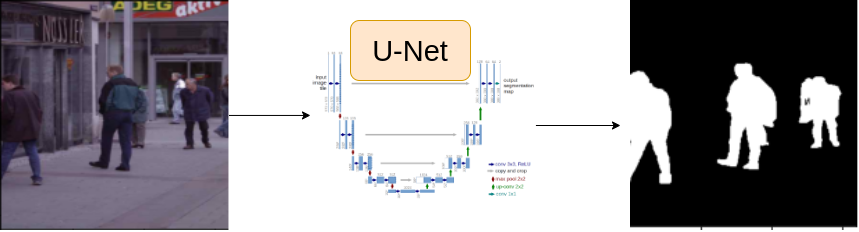

# Some Common Imports

In [4]:
import sys
sys.path.append('/content/Human-Segmentation-Dataset-master')

In [5]:
import torch
import cv2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tqdm import tqdm

import helper

# Task : 2 Setup Configurations

In [35]:
CSV_FILE="/content/Human-Segmentation-Dataset-master/train.csv"
DATA_DIR="/content/"

DEVICE='cuda'

EPOCHS=25
LR = 0.0003
IMAGE_SIZE= 320
BATCH_SIZE = 16

ENCODER='efficientnet-b0'
WEIGHTS ='imagenet'

In [7]:
df=pd.read_csv(CSV_FILE)
df.head()

,masks,images
0,Human-Segmentation-Dataset-master/Ground_Truth...,Human-Segmentation-Dataset-master/Training_Ima...
1,Human-Segmentation-Dataset-master/Ground_Truth...,Human-Segmentation-Dataset-master/Training_Ima...
2,Human-Segmentation-Dataset-master/Ground_Truth...,Human-Segmentation-Dataset-master/Training_Ima...
3,Human-Segmentation-Dataset-master/Ground_Truth...,Human-Segmentation-Dataset-master/Training_Ima...
4,Human-Segmentation-Dataset-master/Ground_Truth...,Human-Segmentation-Dataset-master/Training_Ima...


In [8]:
row = df.iloc[7]
image_path = row.images
mask_path = row.masks

image = cv2.imread(image_path)#opencv read
image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
#opencv to read- BGR=>RGB

mask = cv2.imread(mask_path,cv2.IMREAD_GRAYSCALE)/255.0



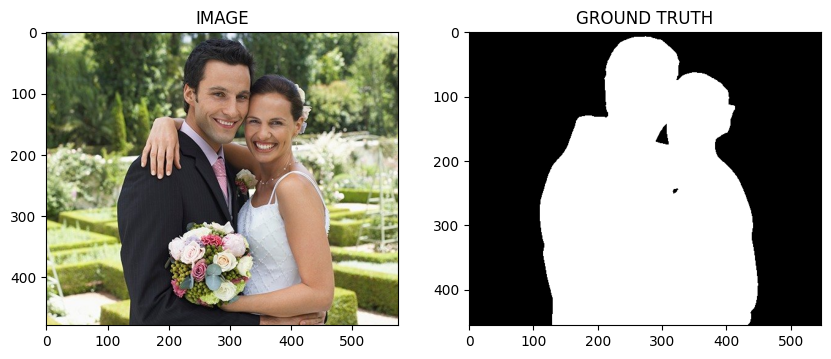

In [9]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

ax1.set_title('IMAGE')
ax1.imshow(image)

ax2.set_title('GROUND TRUTH')
ax2.imshow(mask,cmap = 'grey')

In [10]:
train_df,valid_df = train_test_split(df,test_size = 0.2,random_state=42)

# Task 3 : Augmentation Functions

albumentation documentation : https://albumentations.ai/docs/

In [11]:
import albumentations as A

In [12]:
def get_train_augs():
  return A.Compose([
      A.Resize(IMAGE_SIZE,IMAGE_SIZE),
      A.HorizontalFlip(p=0.5),
      A.VerticalFlip(p=0.5)
  ])

def get_valid_augs():
    return A.Compose([
        A.Resize(IMAGE_SIZE,IMAGE_SIZE)
    ])

# Task 4 : Create Custom Dataset

In [13]:
from torch.utils.data import Dataset

In [14]:
class Segdataset (Dataset):

  def __init__(self,df,augmentations):
    self.df = df
    self.augmentations = augmentations

  def __len__(self):
    return len(self.df)

  def __getitem__(self,idx):
    row = self.df.iloc[idx]

    image_path = row.images
    mask_path = row.masks

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    # Ensure initial spatial dimensions match before augmentation
    image = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE))
    mask = cv2.resize(mask, (IMAGE_SIZE, IMAGE_SIZE))

    mask = np.expand_dims(mask, axis=-1)

    if self.augmentations:
      data = self.augmentations(image=image, mask=mask)
      image = data["image"]
      mask = data["mask"]

    # (h,w,c) --> (c,h,w)
    image = np.transpose(image, (2, 0, 1)).astype(np.float32)
    mask = np.transpose(mask, (2, 0, 1)).astype(np.float32)

    image = torch.Tensor(image) / 255.0. #normalization of the data
    mask = torch.round(torch.Tensor(mask) / 255.0)

    return image, mask

In [15]:
trainset = Segdataset(train_df,get_train_augs())
validset = Segdataset(valid_df,get_valid_augs())

In [16]:
print(f"Size of Trainset : {len(trainset)}")
print(f"Size of Validset : {len(validset)}")

Size of Trainset : 232
Size of Validset : 58


In [17]:
def show_image(image, mask):
    # image shape is (C, H, W), needs to be (H, W, C) for imshow
    image = image.permute(1, 2, 0).cpu().numpy()
    # mask shape is (1, H, W), needs to be (H, W) for imshow
    mask = mask.permute(1, 2, 0).squeeze().cpu().numpy()

    f, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

    ax1.set_title('IMAGE')
    ax1.imshow(image)

    ax2.set_title('GROUND TRUTH')
    ax2.imshow(mask, cmap='gray')

    plt.show()

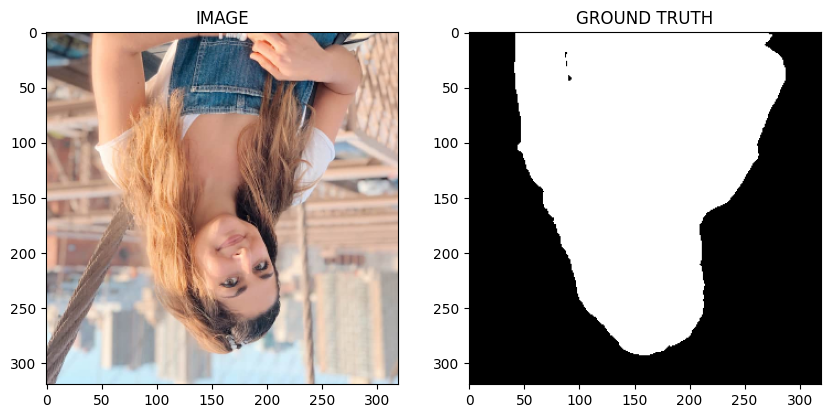

In [28]:
idx = 23
image, mask = trainset[idx]
show_image(image, mask)

# Task 5 : Load dataset into batches

In [22]:
from torch.utils.data import DataLoader

In [23]:
trainloader = DataLoader(trainset,batch_size=BATCH_SIZE,shuffle=True)
validloader = DataLoader(validset,batch_size=BATCH_SIZE)

In [24]:
print(len(trainloader))
print(len(validloader))

15
4


In [26]:
for image,mask in trainloader:
  break

print(f'One batch image shape : {image.shape}')
print(f'One batch mask shape : {mask.shape}')

One batch image shape : torch.Size([16, 3, 320, 320])
One batch mask shape : torch.Size([16, 1, 320, 320])


# Task 6 : Create Segmentation Model

segmentation_models_pytorch documentation : https://smp.readthedocs.io/en/latest/

In [30]:
from torch import nn
import segmentation_models_pytorch as smp
from segmentation_models_pytorch.losses import DiceLoss

In [32]:
class SegmentationModel(nn.Module):

 def __init__(self):
    super(SegmentationModel,self).__init__()

    self.arc = smp.Unet(
        encoder_name=ENCODER,
        encoder_weights=WEIGHTS,
        in_channels=3,
        classes=1,
        activation=None
    )
 def forward(self,images,masks=None):
    logits= self.arc(images)

    if masks != None:
      loss1= DiceLoss(mode='binary')(logits,masks)
      loss2= nn.BCEWithLogitsLoss()(logits,masks)
      return logits,loss1+loss2

    return logits#when testing and inference



In [37]:
model = SegmentationModel()
model.to(DEVICE);

# Task 7 : Create Train and Validation Function

In [38]:
def train_fn(data_loader,model,optimizer):
  model.train()
  total_loss = 0.0

  for images , masks in tqdm(data_loader):
    images = images.to(DEVICE)
    masks = masks.to(DEVICE)

    optimizer.zero_grad()
    logits,loss = model(images,masks)
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  return total_loss/len(data_loader)

In [44]:
def eval_fn(data_loader,model,optimizer):
  model.eval()
  total_loss = 0.0

  with torch.no_grad():
    for images , masks in tqdm(data_loader):
      images = images.to(DEVICE)
      masks = masks.to(DEVICE)

      logits,loss = model(images,masks)

      total_loss += loss.item()

  return total_loss/len(data_loader)

# Task 8 : Train Model

In [40]:
optimizer=torch.optim.Adam(model.parameters(),lr=LR)

In [41]:
best_valid_loss = np.inf

for i in range(EPOCHS):
  train_loss = train_fn(trainloader,model,optimizer)
  valid_loss = eval_fn(validloader,model,optimizer)

  if valid_loss < best_valid_loss:
    torch.save(model.state_dict(),'best_model.pt')
    print("Model Saved")
    best_valid_loss = valid_loss

  print(f"Epoch: {i+1} Train loss: {train_loss} Valid loss :{valid_loss}")

100%|██████████| 4/4 [00:00<00:00,  6.07it/s]


Model Saved
Epoch: 1 Train loss: 1.219139329592387 Valid loss :0.9613725543022156


100%|██████████| 4/4 [00:00<00:00,  4.98it/s]


Model Saved
Epoch: 2 Train loss: 0.7757267554601034 Valid loss :0.9134522080421448


100%|██████████| 4/4 [00:00<00:00,  6.17it/s]


...

Model Saved
Epoch: 23 Train loss: 0.09820470809936524 Valid loss :0.16297175362706184


100%|██████████| 4/4 [00:00<00:00,  6.22it/s]


Epoch: 24 Train loss: 0.08861809621254603 Valid loss :0.17198794521391392


100%|██████████| 4/4 [00:00<00:00,  6.13it/s]


Model Saved
Epoch: 25 Train loss: 0.08717135439316431 Valid loss :0.16265498101711273


# Task 9 : Inference

In [53]:
model.load_state_dict(torch.load('/content/best_model.pt'))

idx=7
image,mask = validset[idx]

logits_mask = model(image.to(DEVICE).unsqueeze(0)) #(c,h,w) -> (1,C,H,W)

pred_mask = torch.sigmoid(logits_mask)
pred_mask = (pred_mask > 0.5) * 1.0


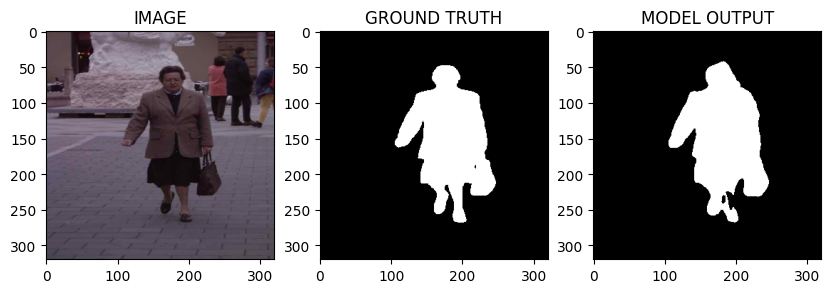

In [54]:
helper.show_image(image, mask, pred_mask.detach().cpu().squeeze(0))